# Data Quality → Cleaning → Preprocessing: A Full Pipeline

> **"Garbage in, garbage out."** — anyone who's ever tried to ship a model on dirty data.

This notebook walks you through the **complete data preparation pipeline** in three parts:

| Part | What we do |
|------|------------|
| **A — Audit** | Build a dirty dataset; detect every quality problem across 6 dimensions |
| **B — Clean** | Drop invalid rows, fix consistency issues, **impute** missing values |
| **C — Preprocess** | Normalize features, detect redundancy, discretize continuous variables |

We deliberately **inject** known bugs into the dataset so you can see exactly what each technique fixes.


---
## Setup — Imports & Color Palette


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.impute import KNNImputer, SimpleImputer

import warnings
warnings.filterwarnings('ignore')

# ── Consistent color palette ───────────────────────────────────────────────
BLUE   = '#38BDF8'
AMBER  = '#FBBF24'
GREEN  = '#4ADE80'
RED    = '#F87171'
PURPLE = '#A78BFA'
MUTED  = '#94A3B8'


---
# 
#   PART A — DATA QUALITY AUDIT        


Before we can clean anything we must **diagnose** it.

Researchers organize quality problems into **six dimensions**:

| # | Dimension | Core Question |
|---|-----------|---------------|
| 1 | **Accuracy** | Are the values correct (within valid domain bounds)? |
| 2 | **Completeness** | Are all values present? |
| 3 | **Consistency** | Do records contradict each other? |
| 4 | **Timeliness** | Is the data current? |
| 5 | **Believability** | Can users trust the source / codes? |
| 6 | **Interpretability** | Is the data documented and understandable? |


## A-1. Build the dirty dataset

We create a 300-row **customer** table and then **intentionally inject** every quality defect listed above.
Real-world datasets look exactly like this — the problems are invisible until you look.


In [30]:
np.random.seed(0)
n = 300

dirty_df = pd.DataFrame({
    'customer_id':   range(1, n + 1),
    'age':           np.random.randint(18, 70, n).astype(float),
    'income_usd':    np.random.lognormal(np.log(50_000), 0.5, n).round(2),
    'city':          np.random.choice(['Kathmandu', 'Pokhara', 'Lalitpur', 'Biratnagar'], n),
    'last_purchase': pd.date_range('2020-01-01', periods=n, freq='1D').strftime('%Y-%m-%d'),
    'status':        np.random.choice(['1', '2', '3'], n),
    'satisfaction':  np.random.randint(1, 6, n).astype(float),
})

# ── Bug 1 | ACCURACY: impossible / out-of-range values ────────────────────
dirty_df.loc[5,  'age']        = 150      # impossible age
dirty_df.loc[12, 'age']        = -5       # impossible age
dirty_df.loc[18, 'income_usd'] = -99_999  # negative income

# ── Bug 2 | COMPLETENESS: missing values ──────────────────────────────────
rng = np.random.default_rng(42)
miss_inc  = rng.choice(n, 60, replace=False)
miss_sat  = rng.choice(n, 40, replace=False)
dirty_df.loc[miss_inc, 'income_usd']  = np.nan
dirty_df.loc[miss_sat, 'satisfaction'] = np.nan

# ── Bug 3 | CONSISTENCY: deceased customers still purchasing ──────────────
dirty_df.loc[[10, 20, 30, 50, 90, 130], 'status']        = '9'            # undocumented code
dirty_df.loc[[10, 20, 30, 60, 80, 120, 140, 200], 'last_purchase'] = '2024-12-01'  # purchased after death?

# ── Bug 4 | TIMELINESS: very old (stale) records ─────────────────────────
dirty_df.loc[50:55, 'last_purchase'] = '2015-01-01'

# ── Bug 5 | BELIEVABILITY / INTERPRETABILITY: status code '9' is undocumented
# (no extra injection needed — already added above)

print('Shape:', dirty_df.shape)
print()
print('First 20 rows (selected columns):')
dirty_df.head(20)

Shape: (300, 7)

First 20 rows (selected columns):


,customer_id,age,income_usd,city,last_purchase,status,satisfaction
0,1,62.0,54345.39,Pokhara,2020-01-01,2,1.0
1,2,65.0,68685.54,Pokhara,2020-01-02,1,1.0
2,3,18.0,164612.69,Kathmandu,2020-01-03,2,1.0
3,4,21.0,80179.09,Lalitpur,2020-01-04,3,5.0
4,5,21.0,31677.67,Biratnagar,2020-01-05,2,5.0
5,6,150.0,87403.13,Lalitpur,2020-01-06,3,4.0
6,7,27.0,25895.50,Lalitpur,2020-01-07,2,3.0
7,8,37.0,39695.22,Pokhara,2020-01-08,3,4.0
8,9,39.0,48322.74,Kathmandu,2020-01-09,1,NaN
9,10,68.0,117765.38,Kathmandu,2020-01-10,2,NaN


## A-2. Six-dimension quality checks

Each check targets a different kind of problem — there is no single `is_clean()` function.


In [31]:
SEP = '─' * 55

# 1. Accuracy
print('── 1. ACCURACY ──────────────────────────────────────────')
bad_age = dirty_df[(dirty_df['age'] < 0) | (dirty_df['age'] > 120)]
bad_inc = dirty_df[dirty_df['income_usd'] < 0]
print(f'   Impossible ages:    {len(bad_age):3d} rows  → values {bad_age["age"].values.tolist()}')
print(f'   Negative incomes:   {len(bad_inc):3d} rows  → values {bad_inc["income_usd"].values.tolist()}')

# 2. Completeness
print(f'\n── 2. COMPLETENESS ──────────────────────────────────────')
for col in dirty_df.columns:
    miss = dirty_df[col].isna().sum()
    if miss > 0:
        pct = miss / len(dirty_df) * 100
        bar = '█' * int(pct / 2)
        print(f'   {col:<16}: {miss:3d} missing ({pct:5.1f}%)  {bar}')

# 3. Consistency
print(f'\n── 3. CONSISTENCY ───────────────────────────────────────')
deceased   = dirty_df[dirty_df['status'] == '9'].index
recent     = dirty_df[dirty_df['last_purchase'] >= '2024-01-01'].index
bad_rows   = sorted(set(deceased) & set(recent))
print(f'   Deceased (status=9) with 2024 purchase: {len(bad_rows)} rows → {bad_rows}')

# 4. Timeliness
print(f'\n── 4. TIMELINESS ────────────────────────────────────────')
stale = dirty_df[dirty_df['last_purchase'] < '2016-01-01']
print(f'   Last purchase before 2016: {len(stale)} rows (stale/outdated)')

# 5. Believability
print(f'\n── 5. BELIEVABILITY ─────────────────────────────────────')
known_codes = {'1', '2', '3'}
unknown     = set(dirty_df['status'].unique()) - known_codes
print(f'   All status codes seen: {sorted(dirty_df["status"].unique())}')
print(f'   Undocumented codes:    {sorted(unknown)}  ← trust issue')

# 6. Interpretability
print(f'\n── 6. INTERPRETABILITY ──────────────────────────────────')
print('   No data dictionary supplied for `status` codes.')
print('   Without it, downstream users cannot safely interpret 1/2/3 either.')

── 1. ACCURACY ──────────────────────────────────────────
   Impossible ages:      2 rows  → values [150.0, -5.0]
   Negative incomes:     1 rows  → values [-99999.0]

── 2. COMPLETENESS ──────────────────────────────────────
   income_usd      :  60 missing ( 20.0%)  ██████████
   satisfaction    :  40 missing ( 13.3%)  ██████

── 3. CONSISTENCY ───────────────────────────────────────
   Deceased (status=9) with 2024 purchase: 3 rows → [10, 20, 30]

── 4. TIMELINESS ────────────────────────────────────────
   Last purchase before 2016: 6 rows (stale/outdated)

── 5. BELIEVABILITY ─────────────────────────────────────
   All status codes seen: ['1', '2', '3', '9']
   Undocumented codes:    ['9']  ← trust issue

── 6. INTERPRETABILITY ──────────────────────────────────
   No data dictionary supplied for `status` codes.
   Without it, downstream users cannot safely interpret 1/2/3 either.


## A-3. Visual quality dashboard

Numbers are dry — a chart communicates the severity at a glance.


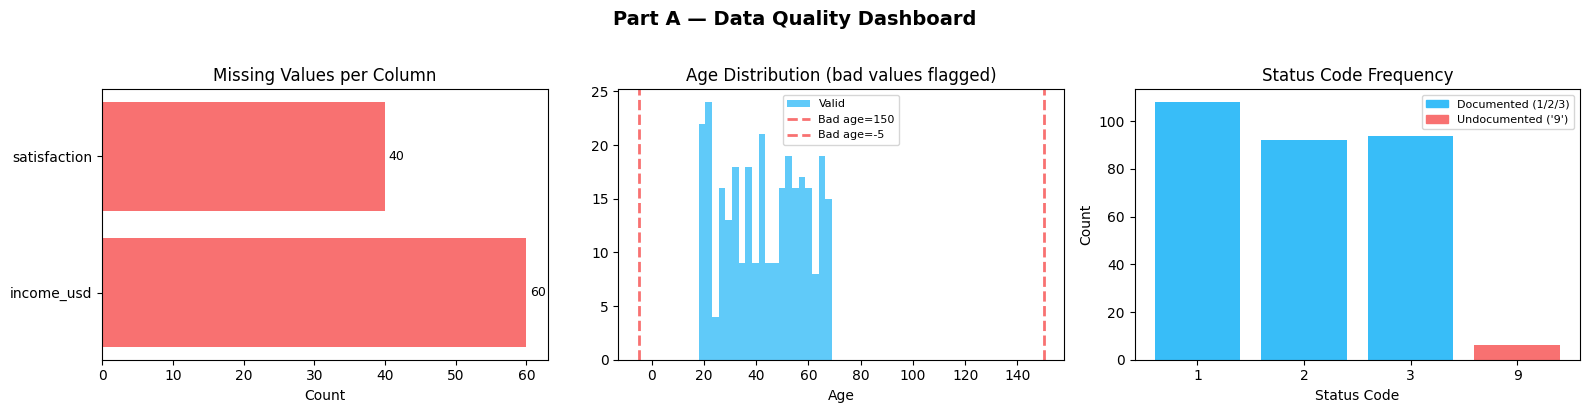

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Part A — Data Quality Dashboard', fontsize=14, fontweight='bold', y=1.02)

# ── Plot 1: Missing values per column ─────────────────────────────────────
miss_counts = dirty_df.isna().sum()
miss_counts = miss_counts[miss_counts > 0]
axes[0].barh(miss_counts.index, miss_counts.values, color=RED)
axes[0].set_title('Missing Values per Column')
axes[0].set_xlabel('Count')
for i, v in enumerate(miss_counts.values):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=9)

# ── Plot 2: Age distribution with impossible values flagged ───────────────
age_clean = dirty_df[(dirty_df['age'] >= 0) & (dirty_df['age'] <= 120)]['age']
age_bad   = dirty_df[(dirty_df['age'] < 0)  | (dirty_df['age'] > 120)]['age']
axes[1].hist(age_clean, bins=20, color=BLUE, alpha=0.8, label='Valid')
for bad in age_bad:
    axes[1].axvline(bad, color=RED, linewidth=2, linestyle='--', label=f'Bad age={bad:.0f}')
axes[1].set_title('Age Distribution (bad values flagged)')
axes[1].set_xlabel('Age')
axes[1].legend(fontsize=8)

# ── Plot 3: Status code frequency (unknown '9' highlighted) ───────────────
status_counts = dirty_df['status'].value_counts().sort_index()
colors = [RED if s == '9' else BLUE for s in status_counts.index]
axes[2].bar(status_counts.index, status_counts.values, color=colors)
axes[2].set_title('Status Code Frequency')
axes[2].set_xlabel('Status Code')
axes[2].set_ylabel('Count')
known_patch   = mpatches.Patch(color=BLUE, label='Documented (1/2/3)')
unknown_patch = mpatches.Patch(color=RED,  label="Undocumented ('9')")
axes[2].legend(handles=[known_patch, unknown_patch], fontsize=8)

plt.tight_layout()
plt.show()

---

#   PART B — CLEANING & IMPUTATION         

Cleaning has two distinct steps:

1. **Drop / Fix** — remove or correct rows that violate hard domain rules or consistency checks.
2. **Impute** — fill in missing values using statistical or model-based strategies.

We always **drop first**, then impute on the surviving rows, so bad values don't corrupt the imputation.


## B-1. Drop & Fix — hard-rule violations

| Problem | Action |
|---------|--------|
| `age` < 0 or > 120 | **Drop** row (impossible person) |
| `income_usd` < 0 | **Drop** row (impossible income) |
| `status = '9'` with purchase ≥ 2024 | **Drop** row (consistency violation) |
| `status = '9'` (otherwise) | **Recode** to `NaN` (undocumented code → treat as unknown) |
| `last_purchase` < 2016 | **Flag** as stale (we'll keep but mark) |


In [33]:
clean_df = dirty_df.copy()

before = len(clean_df)

# ── Step 1: Drop impossible ages ──────────────────────────────────────────
mask_bad_age = (clean_df['age'] < 0) | (clean_df['age'] > 120)
clean_df     = clean_df[~mask_bad_age]
after_age    = len(clean_df)
print(f'Dropped {before - after_age:3d} rows  →  impossible age values')

# ── Step 2: Drop negative incomes ─────────────────────────────────────────
mask_neg_inc = clean_df['income_usd'] < 0
clean_df     = clean_df[~mask_neg_inc]
after_inc    = len(clean_df)
print(f'Dropped {after_age - after_inc:3d} rows  →  negative income values')

# ── Step 3: Drop consistency violations (deceased + recent purchase) ───────
mask_deceased = clean_df['status'] == '9'
mask_recent   = clean_df['last_purchase'] >= '2024-01-01'
mask_conflict = mask_deceased & mask_recent
clean_df      = clean_df[~mask_conflict]
after_consist = len(clean_df)
print(f'Dropped {after_inc - after_consist:3d} rows  →  deceased customer with 2024 purchase')

# ── Step 4: Recode remaining status='9' → NaN (unknowns) ─────────────────
n_recoded = (clean_df['status'] == '9').sum()
clean_df['status'] = clean_df['status'].replace('9', np.nan)
print(f'Recoded {n_recoded:3d} status=9 → NaN  (undocumented code)')

# ── Step 5: Flag stale records (keep, but add boolean column) ─────────────
clean_df['is_stale'] = clean_df['last_purchase'] < '2016-01-01'
n_stale = clean_df['is_stale'].sum()
print(f'Flagged  {n_stale:3d} rows as stale (last_purchase before 2016)')

clean_df.reset_index(drop=True, inplace=True)

print(f'\n📊  Rows remaining: {len(clean_df)} / {before}  ({before - len(clean_df)} total removed)')
print()
print('Missing value summary after dropping:')
print(clean_df.isna().sum()[clean_df.isna().sum() > 0])

Dropped   2 rows  →  impossible age values
Dropped   1 rows  →  negative income values
Dropped   3 rows  →  deceased customer with 2024 purchase
Recoded   3 status=9 → NaN  (undocumented code)
Flagged    6 rows as stale (last_purchase before 2016)

📊  Rows remaining: 294 / 300  (6 total removed)

Missing value summary after dropping:
income_usd      59
status           3
satisfaction    40
dtype: int64


## B-2. Imputation — filling missing values

After dropping hard violations we still have **missing `income_usd`**, **missing `satisfaction`**, and the **recoded `status` NaNs**.  
We compare three strategies:

| Strategy | How it works | Best for |
|----------|-------------|----------|
| **Mean / Mode** | Replace with column average or most frequent value | Quick, symmetric distributions |
| **Median** | Replace with middle value | Skewed distributions / outliers |
| **KNN** | Predict from k nearest neighbours | Correlated features, numeric data |

> **Rule of thumb**  
> — Use **mean** for roughly symmetric numeric columns.  
> — Use **median** when the column is skewed or has outliers.  
> — Use **mode / most-frequent** for categorical columns.  
> — Use **KNN** when you suspect correlations between features.


In [34]:
# ── Identify numeric columns that need imputation ─────────────────────────
numeric_cols = ['income_usd', 'satisfaction', 'age']

print('Missing counts BEFORE imputation:')
print(clean_df[numeric_cols].isna().sum())
print()

# ── Strategy A: Mean imputation ───────────────────────────────────────────
imp_mean = SimpleImputer(strategy='mean')
df_mean  = clean_df.copy()
df_mean[numeric_cols] = imp_mean.fit_transform(clean_df[numeric_cols])

# ── Strategy B: Median imputation ────────────────────────────────────────
imp_median = SimpleImputer(strategy='median')
df_median  = clean_df.copy()
df_median[numeric_cols] = imp_median.fit_transform(clean_df[numeric_cols])

# ── Strategy C: KNN imputation (k=5) ──────────────────────────────────────
imp_knn = KNNImputer(n_neighbors=5)
df_knn  = clean_df.copy()
df_knn[numeric_cols] = imp_knn.fit_transform(clean_df[numeric_cols])

# ── Strategy D: Mode for categorical (status) ─────────────────────────────
mode_status = clean_df['status'].mode()[0]
df_mean  ['status'] = df_mean  ['status'].fillna(mode_status)
df_median['status'] = df_median['status'].fillna(mode_status)
df_knn   ['status'] = df_knn   ['status'].fillna(mode_status)

print(f'Mode used for status NaNs: "{mode_status}"')
print()

# ── Compare imputed vs original statistics ────────────────────────────────
print(f'  {"Column":<15} {"Original":<20} {"Mean-imp":<20} {"Median-imp":<20} {"KNN-imp":<20}')
print('  ' + '─' * 90)
for col in numeric_cols:
    orig  = clean_df[col].mean()
    mn    = df_mean  [col].mean()
    med   = df_median[col].mean()
    knn   = df_knn   [col].mean()
    print(f'  {col:<15} mean={orig:<12.2f}  mean={mn:<12.2f}  mean={med:<12.2f}  mean={knn:<12.2f}')

Missing counts BEFORE imputation:
income_usd      59
satisfaction    40
age              0
dtype: int64

Mode used for status NaNs: "1"

  Column          Original             Mean-imp             Median-imp           KNN-imp             
  ──────────────────────────────────────────────────────────────────────────────────────────
  income_usd      mean=51761.54      mean=51761.54      mean=50638.56      mean=51821.45    
  satisfaction    mean=2.92          mean=2.92          mean=2.93          mean=2.88        
  age             mean=42.93         mean=42.93         mean=42.93         mean=42.93       


## B-3. Visualize: original vs imputed distributions

A good imputation should **preserve the shape** of the distribution, not distort it.


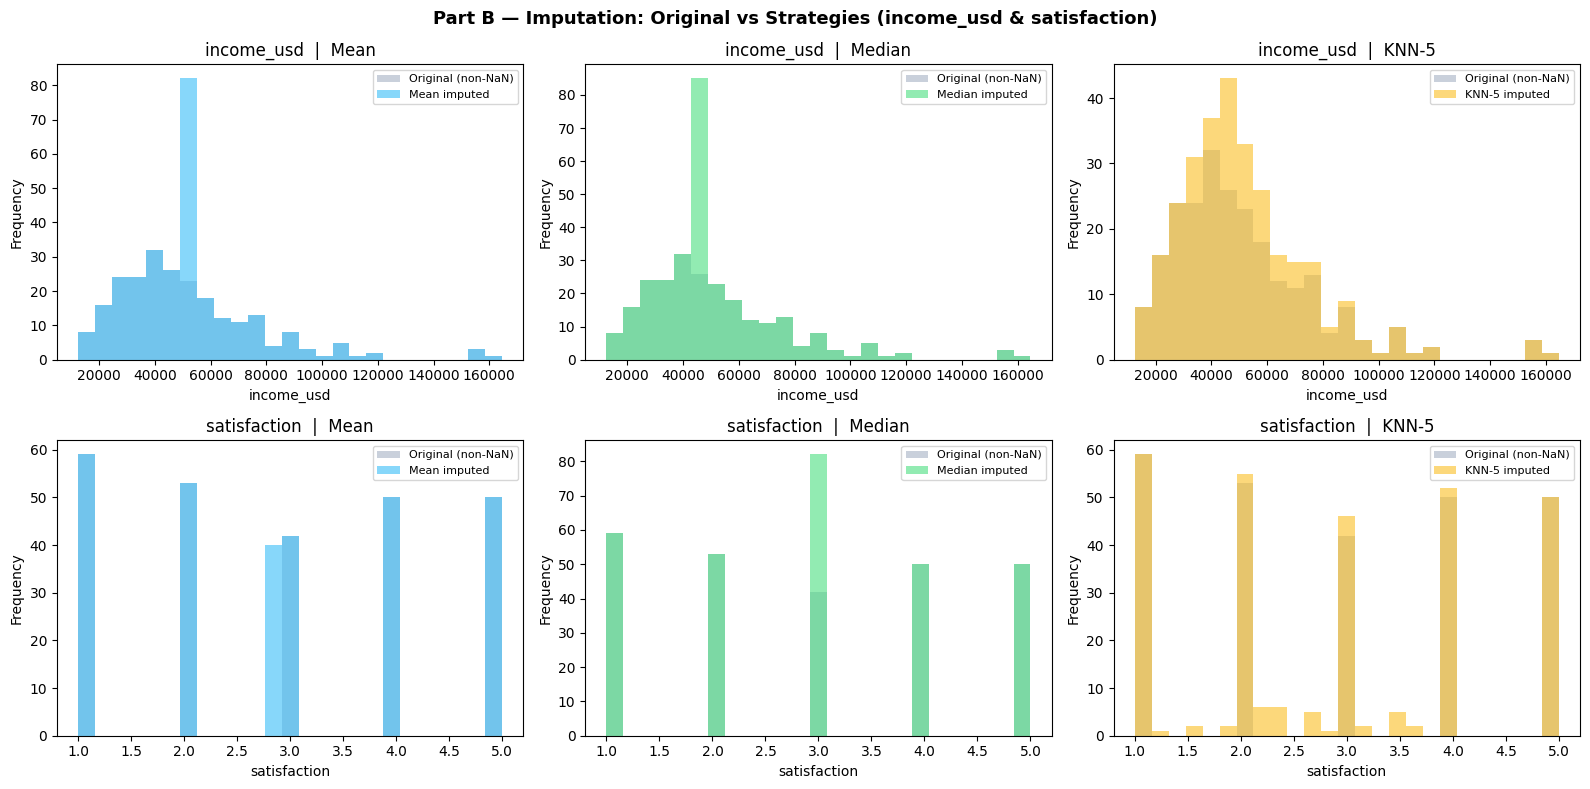

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Part B — Imputation: Original vs Strategies (income_usd & satisfaction)',
             fontsize=13, fontweight='bold')

strategies = [
    ('Mean',   df_mean,   BLUE),
    ('Median', df_median, GREEN),
    ('KNN-5',  df_knn,    AMBER),
]

for col_idx, col in enumerate(['income_usd', 'satisfaction']):
    for strat_idx, (name, df, color) in enumerate(strategies):
        ax = axes[col_idx][strat_idx]

        # original non-missing values
        orig_vals = clean_df[col].dropna()
        ax.hist(orig_vals, bins=25, color=MUTED, alpha=0.5, label='Original (non-NaN)')
        ax.hist(df[col],   bins=25, color=color, alpha=0.6, label=f'{name} imputed')

        ax.set_title(f'{col}  |  {name}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## B-4. Choose a strategy & commit to the clean dataset

For this dataset:
- **`income_usd`** is right-skewed (log-normal) → **median** is safer than mean.
- **`satisfaction`** is an ordinal integer 1–5 → **median** rounds to a valid integer.
- **`status`** is categorical → **mode** (most frequent code).

We commit to **median imputation** and call the result `clean_df`.


In [36]:
# Commit: use median-imputed version as the canonical clean dataset
clean_df = df_median.copy()

# Round satisfaction back to integer (it's ordinal 1–5)
clean_df['satisfaction'] = clean_df['satisfaction'].round().astype(int)

print('=== FINAL CLEAN DATASET ===')
print(f'Rows : {len(clean_df)}')
print(f'Cols : {list(clean_df.columns)}')
print()
print('Missing values remaining:')
miss = clean_df.isna().sum()
if miss.sum() == 0:
    print('  ✅  None — dataset is complete!')
else:
    print(miss[miss > 0])
print()
print(clean_df.describe().round(2))

=== FINAL CLEAN DATASET ===
Rows : 294
Cols : ['customer_id', 'age', 'income_usd', 'city', 'last_purchase', 'status', 'satisfaction', 'is_stale']

Missing values remaining:
  ✅  None — dataset is complete!

       customer_id     age  income_usd  satisfaction
count       294.00  294.00      294.00        294.00
mean        153.23   42.93    50638.56          2.93
std          85.47   15.40    23427.72          1.35
min           1.00   18.00    12499.97          1.00
25%          80.25   29.00    37095.30          2.00
50%         153.50   42.00    46165.66          3.00
75%         226.75   56.00    58316.87          4.00
max         300.00   69.00   164612.69          5.00


---
#   PART C — PREPROCESSING                 

Even after cleaning, raw features often have **incompatible scales** or **continuous ranges** where categories would be more useful.  
Preprocessing transforms the clean data into a form that ML algorithms can consume effectively.

**This part covers:**
- C-1 Normalization (Min-Max, Z-Score, Decimal Scaling)
- C-2 Redundancy detection (Pearson correlation)
- C-3 Discretization (equal-width, equal-frequency, custom bins)


## C-1. Normalization

**Problem**: `income_usd` lives in tens-of-thousands; `age` lives in tens; `satisfaction` lives in 1–5.  
If you compute Euclidean distance (e.g. k-NN, k-means), income dominates simply because its **raw differences are larger**.

**Solution**: rescale every feature to a comparable range.

| Method | Formula | Output range | Outlier-safe? |
|--------|---------|-------------|---------------|
| **Min-Max** | (v − min) / (max − min) | [0, 1] | ❌ |
| **Z-Score** | (v − μ) / σ | Unbounded | ✅ |
| **Decimal** | v / 10ʲ (j = ceil(log₁₀ max)) | (−1, 1) | Moderate |


In [37]:
# ── Helper functions ──────────────────────────────────────────────────────
def minmax(x):
    return (x - x.min()) / (x.max() - x.min())

def zscore(x):
    return (x - x.mean()) / x.std()

def decimal_scale(x):
    j = int(np.ceil(np.log10(np.abs(x).max() + 1)))
    return x / (10 ** j)

# ── Apply to income_usd ───────────────────────────────────────────────────
col = 'income_usd'
x   = clean_df[col]

results = {
    'Original':       x,
    'Min-Max [0,1]':  minmax(x),
    'Z-Score':        zscore(x),
    'Decimal Scale':  decimal_scale(x),
}

print(f'Normalization comparison  ({col})')
print(f'  {"Method":<20} {"Min":>12} {"Max":>12} {"Mean":>12} {"Std":>12}')
print('  ' + '─' * 64)
for name, vals in results.items():
    print(f'  {name:<20} {vals.min():12.4f} {vals.max():12.4f} '
          f'{vals.mean():12.4f} {vals.std():12.4f}')

# ── Build a normalized dataframe ──────────────────────────────────────────
norm_df = clean_df.copy()
for c in ['income_usd', 'age', 'satisfaction']:
    norm_df[f'{c}_mm'] = minmax(clean_df[c])
    norm_df[f'{c}_z']  = zscore(clean_df[c])

print()
print('Normalized columns added to norm_df ✅')

Normalization comparison  (income_usd)
  Method                        Min          Max         Mean          Std
  ────────────────────────────────────────────────────────────────
  Original               12499.9700  164612.6900   50638.5574   23427.7165
  Min-Max [0,1]              0.0000       1.0000       0.2507       0.1540
  Z-Score                   -1.6279       4.8649       0.0000       1.0000
  Decimal Scale              0.0125       0.1646       0.0506       0.0234

Normalized columns added to norm_df ✅


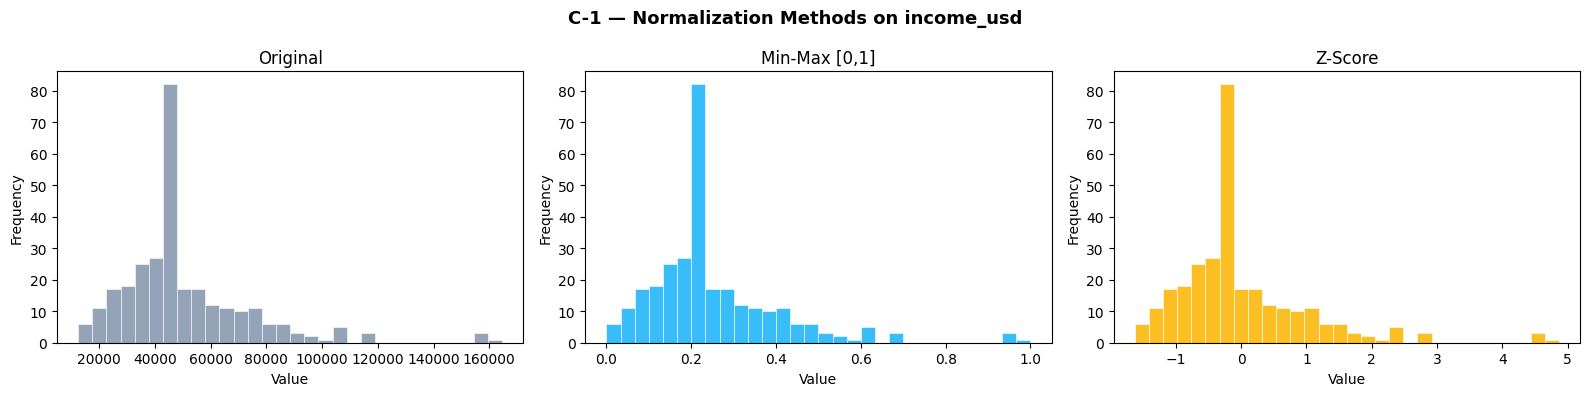

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('C-1 — Normalization Methods on income_usd', fontsize=13, fontweight='bold')

pairs = [
    ('Original',      x,            MUTED),
    ('Min-Max [0,1]', minmax(x),    BLUE),
    ('Z-Score',       zscore(x),    AMBER),
]

for ax, (title, vals, color) in zip(axes, pairs):
    ax.hist(vals, bins=30, color=color, edgecolor='white', linewidth=0.4)
    ax.set_title(title)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## C-2. Redundancy Detection via Correlation

Redundant features waste space, slow down training, and can cause overfitting.  
A **Pearson correlation |r| ≥ 0.95** between two features usually means one is redundant.

We add synthetic duplicate columns to the clean dataset so we can demonstrate the detection.


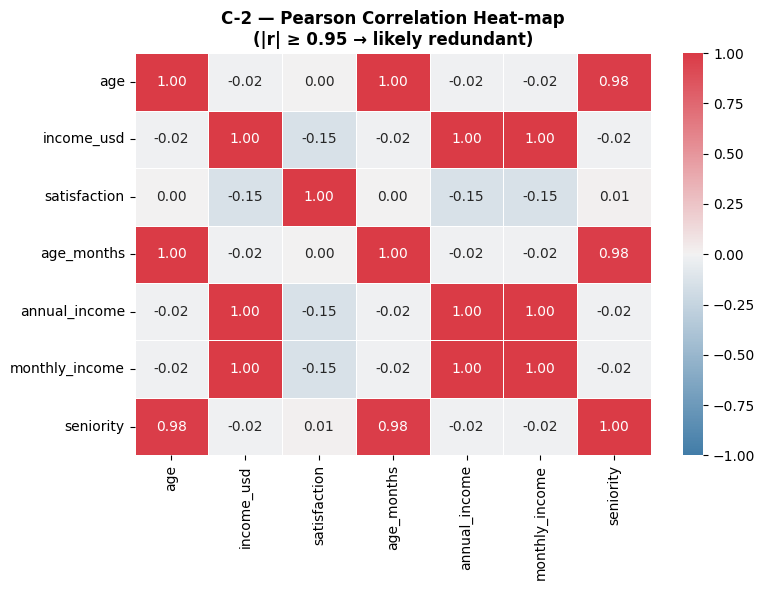

Redundancy report:
  ⚠  |r|=1.000: "age" ↔ "age_months"  → REDUNDANT — drop one!
  ⚠  |r|=0.981: "age" ↔ "seniority"  → REDUNDANT — drop one!
  ⚠  |r|=1.000: "income_usd" ↔ "annual_income"  → REDUNDANT — drop one!
  ⚠  |r|=1.000: "income_usd" ↔ "monthly_income"  → REDUNDANT — drop one!
  ⚠  |r|=0.981: "age_months" ↔ "seniority"  → REDUNDANT — drop one!
  ⚠  |r|=1.000: "annual_income" ↔ "monthly_income"  → REDUNDANT — drop one!


In [39]:
# ── Add synthetic duplicate / near-duplicate columns ──────────────────────
redundancy_df = clean_df[['age', 'income_usd', 'satisfaction']].copy()
redundancy_df['age_months']    = redundancy_df['age'] * 12                       # perfect duplicate
redundancy_df['annual_income'] = redundancy_df['income_usd']                     # perfect duplicate
redundancy_df['monthly_income']= redundancy_df['income_usd'] / 12               # perfect duplicate (scaled)
redundancy_df['seniority']     = redundancy_df['age'] + np.random.normal(0, 3, len(redundancy_df))  # ~0.97 r

corr = redundancy_df.corr()

# ── Heat-map ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
cmap = sns.diverging_palette(240, 10, as_cmap=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap=cmap, center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('C-2 — Pearson Correlation Heat-map\n(|r| ≥ 0.95 → likely redundant)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Auto-report ───────────────────────────────────────────────────────────
THRESHOLD_DROP = 0.95
THRESHOLD_WARN = 0.80

print('Redundancy report:')
cols = corr.columns.tolist()
found_any = False
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = abs(corr.iloc[i, j])
        c1, c2 = cols[i], cols[j]
        if r >= THRESHOLD_DROP:
            print(f'  ⚠  |r|={r:.3f}: "{c1}" ↔ "{c2}"  → REDUNDANT — drop one!')
            found_any = True
        elif r >= THRESHOLD_WARN:
            print(f'  ℹ  |r|={r:.3f}: "{c1}" ↔ "{c2}"  → high correlation, review')
            found_any = True
if not found_any:
    print('  ✅  No redundant pairs found.')

## C-3. Discretization (Binning)

Some algorithms (e.g. decision trees, association rule mining) work better with **categorical ranges** than with raw continuous values.  
Discretization converts a continuous column into ordered bins.

We compare three strategies on `income_usd`:

| Strategy | How bins are determined | Good when |
|----------|------------------------|----------|
| **Equal-width** | Range split into N equal intervals | Data is roughly uniform |
| **Equal-frequency** | Each bin holds ~same # of records | Data is skewed |
| **Custom / Domain** | Expert-defined thresholds | You have domain knowledge |


In [40]:
disc_df = clean_df[['income_usd']].copy()

N_BINS = 5
LABELS = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

# ── Equal-width binning ───────────────────────────────────────────────────
disc_df['ew_bin'] = pd.cut(disc_df['income_usd'], bins=N_BINS, labels=LABELS)

# ── Equal-frequency (quantile) binning ────────────────────────────────────
disc_df['ef_bin'] = pd.qcut(disc_df['income_usd'].rank(method='first'), q=N_BINS, labels=LABELS)

# ── Custom / domain-driven binning ────────────────────────────────────────
custom_edges  = [0, 20_000, 40_000, 70_000, 120_000, np.inf]
custom_labels = ['<20K', '20–40K', '40–70K', '70–120K', '>120K']
disc_df['custom_bin'] = pd.cut(disc_df['income_usd'], bins=custom_edges, labels=custom_labels)

print('Value counts for each strategy:')
print()
for col, label in [('ew_bin', 'Equal-Width'), ('ef_bin', 'Equal-Frequency'), ('custom_bin', 'Custom')]:
    print(f'  [{label}]')
    print(disc_df[col].value_counts().sort_index().to_string())
    print()

Value counts for each strategy:

  [Equal-Width]
ew_bin
Very Low     104
Low          149
Medium        29
High           8
Very High      4

  [Equal-Frequency]
ef_bin
Very Low     59
Low          59
Medium       58
High         59
Very High    59

  [Custom]
custom_bin
<20K         9
20–40K      80
40–70K     158
70–120K     43
>120K        4



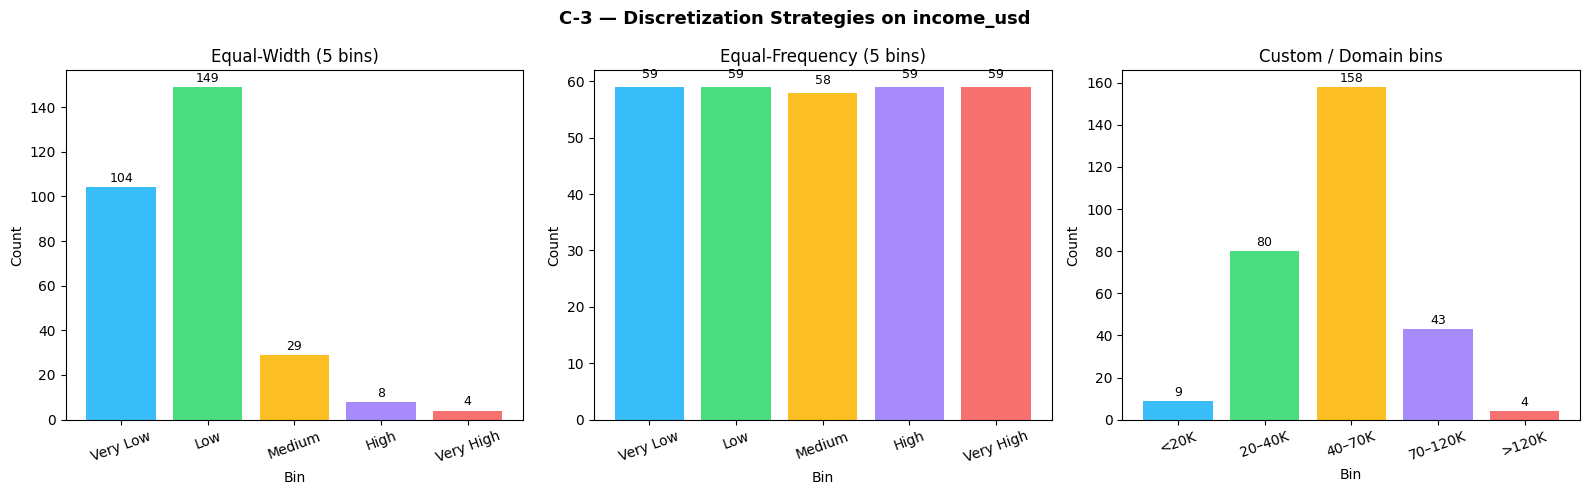

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('C-3 — Discretization Strategies on income_usd', fontsize=13, fontweight='bold')

palette = [BLUE, GREEN, AMBER, PURPLE, RED]

for ax, (col, title) in zip(axes, [
    ('ew_bin',     'Equal-Width (5 bins)'),
    ('ef_bin',     'Equal-Frequency (5 bins)'),
    ('custom_bin', 'Custom / Domain bins'),
]):
    counts = disc_df[col].value_counts().sort_index()
    bars = ax.bar(counts.index.astype(str), counts.values,
                  color=palette[:len(counts)])
    ax.set_title(title)
    ax.set_xlabel('Bin')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 1, str(v),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [42]:
print("=== Final Cleaned Dataset Summary ===")
print(f"Final Rows: {len(clean_df)}")
print(f"Remaining Missing Values: {clean_df.isna().sum()}")
print(f"Remaining Missing Values: {clean_df.isna().sum().sum()}")
print("\n=== Sample of Cleaned Data (First 10 rows) ===")
clean_df.head(10)

=== Final Cleaned Dataset Summary ===
Final Rows: 294
Remaining Missing Values: customer_id      0
age              0
income_usd       0
city             0
last_purchase    0
status           0
satisfaction     0
is_stale         0
dtype: int64
Remaining Missing Values: 0

=== Sample of Cleaned Data (First 10 rows) ===


,customer_id,age,income_usd,city,last_purchase,status,satisfaction,is_stale
0,1,62.0,54345.39,Pokhara,2020-01-01,2,1,False
1,2,65.0,68685.54,Pokhara,2020-01-02,1,1,False
2,3,18.0,164612.69,Kathmandu,2020-01-03,2,1,False
3,4,21.0,80179.09,Lalitpur,2020-01-04,3,5,False
4,5,21.0,31677.67,Biratnagar,2020-01-05,2,5,False
5,7,27.0,25895.50,Lalitpur,2020-01-07,2,3,False
6,8,37.0,39695.22,Pokhara,2020-01-08,3,4,False
7,9,39.0,48322.74,Kathmandu,2020-01-09,1,3,False
8,10,68.0,117765.38,Kathmandu,2020-01-10,2,3,False
9,12,41.0,33075.86,Biratnagar,2020-01-12,2,1,False


---
#  Summary

| Stage | What we did | Rows | Missing |
|-------|------------|------|---------|
| **Raw dirty data** | Injected 5 types of quality bugs | 300 | 100+ |
| **After Part A** | Audited all 6 quality dimensions | 300 | — |
| **After Part B-1 (Drop/Fix)** | Removed impossible values & inconsistencies | 294 | Reduced |
| **After Part B-2 (Impute)** | Filled remaining NaNs via Median + Mode | 294 | **0** |
| **After Part C** | Normalized features; detected redundancy; discretized income | 294 | **0** |

### Key takeaways

1. **Audit first, clean second** — you can't fix what you haven't measured.
2. **Drop before impute** — bad values corrupt imputation statistics.
3. **Median > Mean** for skewed numeric data (income is log-normal).
4. **KNN imputation** exploits feature correlations but is expensive for large datasets.
5. **Normalization** is mandatory before any distance-based algorithm.
6. **Equal-frequency binning** produces balanced bins for skewed distributions; equal-width often produces empty extreme bins.
